In [24]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np
import h5py

### Loading the raw files

The dataset is distributed as MATLAB v7.3 files, which are HDF5 underneath.
`scipy.io.loadmat` cannot read this format - `h5py` is required.

Every field is stored as an **HDF5 object reference**: an address, not the data.
It must be dereferenced through the file handle, so the recurring pattern is
`f[batch['summary'][i, 0]]`. Materialise the array with `[()]`; `.value` was
removed in h5py 3.x.

In [26]:
f1 = h5py.File('2017-05-12_batchdata_updated_struct_errorcorrect.mat', 'r')
batch1 = f1['batch']

f2 = h5py.File('2017-06-30_batchdata_updated_struct_errorcorrect.mat', 'r')
batch2 = f2['batch']

f3 = h5py.File('2018-04-12_batchdata_updated_struct_errorcorrect.mat', 'r')
batch3 = f3['batch']


In [27]:
print(batch1['summary'].shape[0])
print(batch2['summary'].shape[0])
print(batch3['summary'].shape[0])

46
48
46


## Part 1 - Data structure orientation

Understanding the layout. 

In [28]:
list(f1.keys())

['#refs#', '#subsystem#', 'batch', 'batch_date']

In [29]:
list(batch1.keys())

['Vdlin',
 'barcode',
 'channel_id',
 'cycle_life',
 'cycles',
 'policy',
 'policy_readable',
 'summary']

### 1.1 What a single cycle contains/looks like

In [30]:
c = f1[batch1['cycles'][0, 0]]
print("Cycle keys:", list(c.keys()))

Cycle keys: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']


In [31]:
v = f1[c['V'][0, 0]][()].ravel()
print(v.shape, v.min(), v.max())

(2,) 0 0


In [32]:
cycle_idx = 1   # choose the cycle number you want

# Load raw arrays
V  = f1[c['V'][cycle_idx, 0]][()].ravel()
I  = f1[c['I'][cycle_idx, 0]][()].ravel()
T  = f1[c['T'][cycle_idx, 0]][()].ravel()
Qd = f1[c['Qd'][cycle_idx, 0]][()].ravel()
Qc = f1[c['Qc'][cycle_idx, 0]][()].ravel()
t  = f1[c['t'][cycle_idx, 0]][()].ravel()

# Build a tabular DataFrame
df_cycle = pd.DataFrame({
    "time_s": t,
    "voltage_V": V,
    "current_A": I,
    "temperature_C": T,
    "Q_discharge_Ah": Qd,
    "Q_charge_Ah": Qc
})

df_cycle


,time_s,voltage_V,current_A,temperature_C,Q_discharge_Ah,Q_charge_Ah
0,0.000000,2.026416,0.000000,31.632496,0.000000,0.000000
1,0.002417,2.039388,0.215908,31.632496,0.000000,0.000001
2,0.002912,2.051660,0.359831,31.632496,0.000000,0.000001
3,0.003212,2.063070,0.467846,31.632496,0.000000,0.000001
4,0.003498,2.076204,0.575877,31.632496,0.000000,0.000001
...,...,...,...,...,...,...
1082,54.357120,1.999842,-0.034227,31.712118,1.070688,1.071042
1083,54.358155,2.002296,-0.034227,31.712118,1.070689,1.071042
1084,54.365115,2.012406,-0.034227,31.712118,1.070689,1.071042
1085,54.372673,2.022461,-0.034227,31.712118,1.070689,1.071042


In [33]:
df_cycle[650:675]

,time_s,voltage_V,current_A,temperature_C,Q_discharge_Ah,Q_charge_Ah
650,33.856615,3.599870,0.047934,29.625114,0.000000,1.070603
651,33.939928,3.599814,0.047934,29.612093,0.000000,1.070676
652,34.023288,3.599790,0.047869,29.619164,0.000000,1.070750
653,34.106608,3.599761,0.047898,29.628511,0.000000,1.070823
654,34.189852,3.599794,0.047905,29.609203,0.000000,1.070896
655,34.273242,3.599821,0.047900,29.604231,0.000000,1.070969
656,34.356535,3.599888,0.047893,29.585907,0.000000,1.071042
657,34.356583,3.599879,0.047895,29.585907,0.000000,1.071042
658,34.358435,3.589563,-0.439630,29.585907,0.000000,1.071042
659,34.359667,3.578016,-0.920006,29.585907,0.000000,1.071042


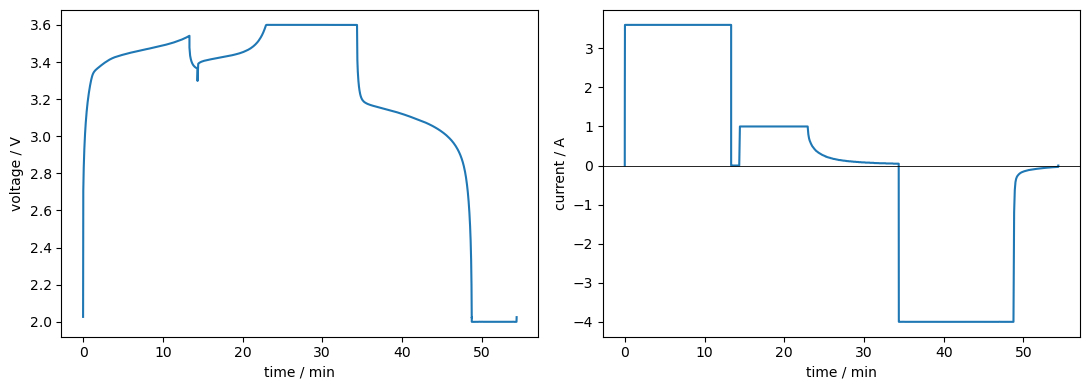

V max: 3.6003742 at row 479 of 1087


In [34]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, V); ax[0].set_ylabel('voltage / V')
ax[1].plot(t, I); ax[1].set_ylabel('current / A'); ax[1].axhline(0, c='k', lw=0.6)
for a in ax: a.set_xlabel('time / min')
plt.tight_layout(); plt.show()

print("V max:", V.max(), "at row", V.argmax(), "of", len(V))

The voltage and current traces show the two-stage fast-charge protocol,
then the constant 4C discharge that is identical across all 124 cells. Charging
protocol is therefore the only deliberate experimental variable.

### 1.2 What each battery life cylce looks - from 1st cycle till battery end of life

In [35]:
cycle_idx = 1
print("V     :", f1[c['V'][cycle_idx, 0]][()].ravel().shape)
print("Qdlin :", f1[c['Qdlin'][cycle_idx, 0]][()].ravel().shape)
print("Tdlin :", f1[c['Tdlin'][cycle_idx, 0]][()].ravel().shape)
print("dQdV  :", f1[c['discharge_dQdV'][cycle_idx, 0]][()].ravel().shape)
print("Vdlin :", f1[batch1['Vdlin'][0, 0]][()].ravel().shape)

V     : (1087,)
Qdlin : (1000,)
Tdlin : (1000,)
dQdV  : (1000,)
Vdlin : (1000,)


In [36]:
i = 0  # battery index
ref = batch1['summary'][i, 0]     # HDF5 reference
battery_summary = f1[ref]         # battery-level summary struct

list(battery_summary.keys())

['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']

In [37]:
i = 0                                    # cell b1c0
s = f1[batch1['summary'][i, 0]]

cyc_df = pd.DataFrame({k: np.asarray(s[k]).ravel() for k in s.keys()})
print(cyc_df.shape)
cyc_df.head(10)

(1189, 8)


,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0
2,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0
3,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0
4,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0
5,0.016623,1.073491,1.073576,31.961062,35.711758,29.752932,13.340835,6.0
6,0.016600,1.073922,1.073992,31.900562,35.615650,29.564377,13.340198,7.0
7,0.016577,1.074158,1.074374,31.921668,35.546783,29.628630,13.425442,8.0
8,0.016588,1.074337,1.074492,31.870082,35.539406,29.597345,13.425190,9.0
9,0.016572,1.074353,1.074537,31.841053,35.499729,29.687315,13.425633,10.0


In [38]:
cyc_df.tail(5)

,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
1184,0.017084,1.026296,1.026472,32.305923,36.718185,29.846605,13.341380,1185.0
1185,0.017078,1.026559,1.026700,32.307072,36.600224,29.723915,13.425378,1186.0
1186,0.017085,1.026315,1.026499,32.296148,36.750278,29.727167,13.425498,1187.0
1187,0.017072,1.026620,1.026677,32.208778,36.758877,29.654888,13.340972,1188.0
1188,0.017089,1.026054,1.026210,32.200804,36.561554,29.681129,13.425712,1189.0


### 1.3 Cell Inventory 
One row per stored record, across all three batches.

- `scalar()` dereferences a single-value field and flattens it
- `text()` decodes MATLAB UTF-16 character arrays by taking every second byte
- `early_value()` averages the first *n* strictly positive entries, which skips
  the placeholder zeros present in batch 1's opening rows

In [39]:
def scalar(f, ref):
    return np.asarray(f[ref][()]).ravel()[0]

def text(f, ref):
    return f[ref][()].tobytes()[::2].decode('utf-8', errors='replace')
  

In [40]:
def early_value(arr, n=5):
    """Mean of the first n strictly positive entries."""
    good = arr[arr > 0]
    if len(good) == 0:
        return np.nan
    return good[:n].mean()

### Building the cell inventory table

In [41]:
def batch_table(f, batch, label):
    rows = []
    for i in range(batch['summary'].shape[0]):
        s = f[batch['summary'][i, 0]]
        qd = np.asarray(s['QDischarge']).ravel()
        ir = np.asarray(s['IR']).ravel()
        rows.append({
            'cell_id':     f'{label}c{i}',
            'policy':      text(f, batch['policy_readable'][i, 0]),
            'cycle_life':  scalar(f, batch['cycle_life'][i, 0]),
            'n_cycles':    len(qd),
            'Q_initial':  early_value(qd),
            'Q_last':      qd[-1],
            'IR_initial': early_value(ir),
            'IR_last':     ir[-1],
        })
    return pd.DataFrame(rows).set_index('cell_id')

In [42]:
t1 = batch_table(f1, batch1, 'b1')
t2 = batch_table(f2, batch2, 'b2')
t3 = batch_table(f3, batch3, 'b3')

print(t1.shape, t2.shape, t3.shape)   # expect (46,8) (48,8) (46,8)
t1

(46, 7) (48, 7) (46, 7)


,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last
cell_id,,,,,,,
b1c0,3.6C(80%)-3.6C,1190.0,1189,1.072370,1.026210,0.016687,0.017089
b1c1,3.6C(80%)-3.6C,1179.0,1178,1.077181,1.038225,0.016950,0.017363
b1c2,3.6C(80%)-3.6C,1177.0,1176,1.081847,1.043279,0.016760,0.017273
b1c3,4C(80%)-4C,1226.0,1225,1.081758,0.970921,0.016326,0.017057
b1c4,4C(80%)-4C,1227.0,1226,1.079671,1.021960,0.016734,0.017073
b1c5,4.4C(80%)-4.4C,1074.0,1073,1.077600,0.880536,0.016359,0.019527
b1c6,4.8C(80%)-4.8C,636.0,635,1.078115,0.880057,0.016926,0.020405
b1c7,4.8C(80%)-4.8C,870.0,869,1.095673,0.881106,0.016241,0.019942
b1c8,5.4C(40%)-3.6C,879.0,878,1.091791,0.969025,0.016753,0.017866


In [43]:
t1.policy.dtype

dtype('O')

In [44]:
all_cells = pd.concat(
    [t1.assign(batch=1), t2.assign(batch=2), t3.assign(batch=3)]
)
print(all_cells.shape)                # (140, 9)
all_cells

(140, 8)


,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last,batch
cell_id,,,,,,,,
b1c0,3.6C(80%)-3.6C,1190.0,1189,1.072370,1.026210,0.016687,0.017089,1
b1c1,3.6C(80%)-3.6C,1179.0,1178,1.077181,1.038225,0.016950,0.017363,1
b1c2,3.6C(80%)-3.6C,1177.0,1176,1.081847,1.043279,0.016760,0.017273,1
b1c3,4C(80%)-4C,1226.0,1225,1.081758,0.970921,0.016326,0.017057,1
b1c4,4C(80%)-4C,1227.0,1226,1.079671,1.021960,0.016734,0.017073,1
...,...,...,...,...,...,...,...,...
b3c41,5.6C(36%)-4.3C-newstructure,786.0,785,1.051153,0.880623,0.018507,0.021188,3
b3c42,4.8C(80%)-4.8C-newstructure,1642.0,1641,1.067409,0.880375,0.016358,0.018658,3
b3c43,5C(67%)-4C-newstructure,1046.0,1045,1.070636,0.880607,0.015859,0.019207,3


In [45]:
all_cells.groupby('batch')[['cycle_life', 'n_cycles', 'Q_initial']].describe().T

batch                       1            2            3
cycle_life count    46.000000    48.000000    44.000000
           mean    844.717391   494.708333  1059.659091
           std     184.629198   141.111388   313.869692
           min     534.000000   148.000000   541.000000
           25%     703.250000   461.000000   828.000000
           50%     858.500000   483.000000  1005.500000
           75%     914.250000   503.750000  1155.250000
           max    1227.000000  1061.000000  1935.000000
n_cycles   count    46.000000    48.000000    46.000000
           mean    843.717391   519.166667  1108.847826
           std     184.629198   138.294834   388.341143
           min     533.000000   170.000000   540.000000
           25%     702.250000   486.750000   832.500000
           50%     857.500000   508.000000  1017.500000
           75%     913.250000   533.250000  1156.500000
           max    1226.000000  1060.000000  2237.000000
Q_initial  count    46.000000    48.000000    46.000000
           mean      1.079767     1.065697     1.064400
           std       0.007666     0.020820     0.007194
           min       1.055643     0.971033     1.047037
           25%       1.076478     1.068258     1.061230
           50%       1.080096     1.071420     1.066315
           75%       1.083496     1.075270     1.069232
           max       1.096396     1.083738     1.074698

In [46]:
all_cells.iloc[[5]]

,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last,batch
cell_id,,,,,,,,
b1c5,4.4C(80%)-4.4C,1074.0,1073,1.0776,0.880536,0.016359,0.019527,1


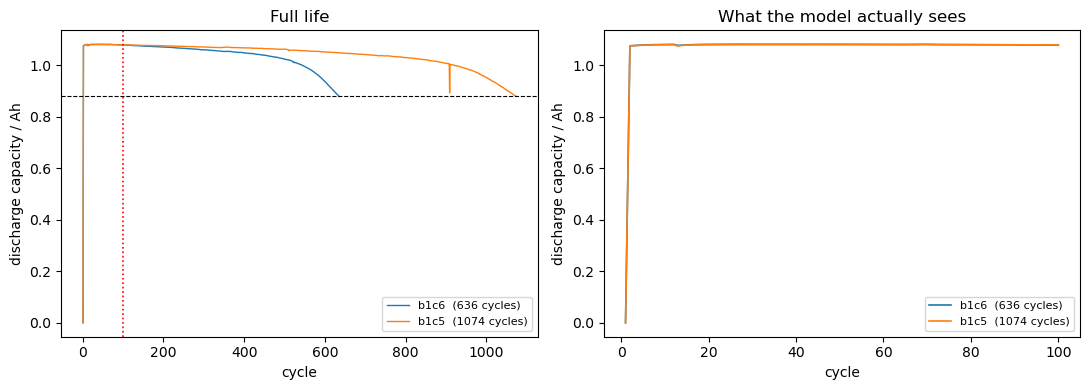

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for idx, lab in [(6, 'b1c6  (636 cycles)'), (5, 'b1c5  (1074 cycles)')]:
    s   = f1[batch1['summary'][idx, 0]]
    qd  = np.asarray(s['QDischarge']).ravel()
    cyc = np.asarray(s['cycle']).ravel()
    ax[0].plot(cyc, qd, lw=1, label=lab)
    ax[1].plot(cyc[:100], qd[:100], lw=1.2, label=lab)

ax[0].axhline(0.88, ls='--', c='k', lw=0.8)   # end of life
ax[0].axvline(100,  ls=':',  c='r', lw=1.2)   # prediction point
ax[0].set_title('Full life')
ax[1].set_title('What the model actually sees')

for a in ax:
    a.set_xlabel('cycle'); a.set_ylabel('discharge capacity / Ah'); a.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Part 2 - Exploratory Data Analysis (EDA)

In [48]:
all_cells.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, b1c0 to b3c45
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   policy      140 non-null    object 
 1   cycle_life  138 non-null    float64
 2   n_cycles    140 non-null    int64  
 3   Q_initial   140 non-null    float64
 4   Q_last      140 non-null    float64
 5   IR_initial  140 non-null    float64
 6   IR_last     140 non-null    float64
 7   batch       140 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 9.8+ KB


### Finding cells with unreliable cycle life

`cycle_life` is defined as the cycle at which discharge capacity falls to 0.88 Ah — 80% of the 1.1 Ah nominal capacity. A cell that reached end of life must therefore have a final capacity at or below 0.88 Ah.
This filter looks for the opposite: cells whose **last recorded capacity is still above 0.885 Ah**. Those cells were healthy when recording stopped, so they never died — and their `cycle_life` value cannot be a real death cycle.
(0.885 rather than 0.880 leaves a small margin so measurement noise doesn't flag a cell that genuinely failed.)

**12 cells found.** Confirming they're broken: for every one of them, `cycle_life = n_cycles + 1`. The recorded "lifetime" is just the number of rows in the file, not an observed failure. For `b3c23` and `b3c32` the file carries no value at all — `cycle_life` is NaN.

In [49]:
print(all_cells[all_cells.Q_last > 0.885][['batch','cycle_life','Q_last','n_cycles']])

         batch  cycle_life    Q_last  n_cycles
cell_id                                       
b1c0         1      1190.0  1.026210      1189
b1c1         1      1179.0  1.038225      1178
b1c2         1      1177.0  1.043279      1176
b1c3         1      1226.0  0.970921      1225
b1c4         1      1227.0  1.021960      1226
b1c8         1       879.0  0.969025       878
b1c10        1       906.0  0.961019       905
b1c12        1       902.0  0.913119       901
b1c13        1       897.0  0.923136       896
b1c22        1       891.0  0.963279       890
b3c23        3         NaN  0.937011      2189
b3c32        3         NaN  0.973883      2237


These split into two groups:

- **`b1c0`–`b1c4`** — capacity 0.97–1.04, far above threshold. These are the five cells whose tests were still running when batch 1's file was written (as per the publication); the rest of their lives is recorded in batch 2 under different IDs. So in batch 1 only 1st part of the lifecylce is recorded and the 2nd part is recorded in batch 2. The partner cells in batch 2 should be identified and either removed along with their partners in batch 1 or stitched together. I followed the first approach. 
- **`b1c8, b1c10, b1c12, b1c13, b1c22, b3c23, b3c32`** — tests stopped for other reasons before end of life

All 12 are excluded: a supervised model cannot learn from a fabricated target.

**Note this filter cannot catch everything.** The batch-2 continuation records (`b2c7, b2c8, b2c9, b2c15, b2c16`) did run to death, so their `Q_last` is legitimately below 0.88 and they pass this test. They are identified separately — see the next section.

### Identifying the batch-2 continuation records:
This step is done to i dentify those continuation record for the 5 cells in batch 2 without taking the directly from the paper. 
- **For a continuos recording, the Q_last of the last record should be very close to the Q_initial of the next record for the same cell.**

In [50]:
pd.set_option('display.max_colwidth', None)
targets = all_cells.loc[['b1c0','b1c1','b1c2','b1c3','b1c4'], ['policy','Q_last']]
b2 = all_cells[all_cells.batch == 2]

for cid, row in targets.iterrows():
    diff = (b2.Q_initial - row.Q_last).abs()
    best = diff.nsmallest(3)
    print(f"\n{cid}   policy: {row.policy}   Q_last: {row.Q_last:.6f}")
    print(b2.loc[best.index, ['policy','Q_initial','cycle_life']]
            .assign(diff=best.round(6)))


b1c0   policy: 3.6C(80%)-3.6C   Q_last: 1.026210
            policy  Q_initial  cycle_life      diff
cell_id                                            
b2c8     80%)-3.6C   1.027222       982.0  0.001012
b2c7     80%)-3.6C   1.023079       663.0  0.003130
b2c9     80%)-3.6C   1.032445      1061.0  0.006235

b1c1   policy: 3.6C(80%)-3.6C   Q_last: 1.038225
               policy  Q_initial  cycle_life      diff
cell_id                                               
b2c47      6C(60%)-3C   1.043152       713.0  0.004927
b2c9        80%)-3.6C   1.032445      1061.0  0.005780
b2c19    4.4C(55%)-6C   1.048054       461.0  0.009830

b1c2   policy: 3.6C(80%)-3.6C   Q_last: 1.043279
               policy  Q_initial  cycle_life      diff
cell_id                                               
b2c47      6C(60%)-3C   1.043152       713.0  0.000127
b2c19    4.4C(55%)-6C   1.048054       461.0  0.004776
b2c9        80%)-3.6C   1.032445      1061.0  0.010834

b1c3   policy: 4C(80%)-4C   Q_last: 0.9

Nearest-capacity matching: for each batch-1 cell, the batch-2 cell whose
`Q_initial` is closest to that cell's `Q_last`.

| batch 1 cell | nearest match in batch 2 | capacity gap (Ah) | listed in Severson et al. |
|---|---|---|---|
| b1c0 | b2c8  | 0.001012 | b2c7  |
| b1c1 | b2c47 | 0.004927 | b2c8  |
| b1c2 | b2c47 | 0.000127 | b2c9  |
| b1c3 | b2c15 | 0.000112 | b2c15 |
| b1c4 | b2c7  | 0.001120 | b2c16 |

Nearest-capacity matching identifies the correct **set** of records (`b2c7`, `b2c8`, `b2c9`, `b2c15` all appear) but assigns the **pairings** unreliably. Only `b1c3` → `b2c15` agrees with the published list.
The reason is visible in the numbers: `b1c0`–`b1c2` end at 1.026, 1.038 and 1.043 Ah, values within 0.02 Ah of each other and close to what a fresh batch-2 cell starts at (median `Q_initial` = 1.0714). Capacity alone cannot separate them. `b1c3` matched cleanly only because 0.971 Ah is low enough to be unambiguous.

Pairings are not required for exclusion — the set is. It was confirmed by three independent signals in the data (see below).

### Confirming the set with three independent signals

Nearest-capacity matching gives an unreliable pairing, so the candidate set is
tested against three further signals. `b2c47` is included as a control — it was
the strongest non-listed candidate from the matching above.

In [51]:
b2 = all_cells[all_cells.batch == 2]
print("batch 2 median Q_initial:", round(b2.Q_initial.median(), 4))
print(b2.loc[['b2c7','b2c8','b2c9','b2c15','b2c16','b2c47'],
             ['policy','Q_initial','cycle_life','n_cycles']])

batch 2 median Q_initial: 1.0714
             policy  Q_initial  cycle_life  n_cycles
cell_id                                             
b2c7      80%)-3.6C   1.023079       663.0       662
b2c8      80%)-3.6C   1.027222       982.0       981
b2c9      80%)-3.6C   1.032445      1061.0      1060
b2c15       80%)-4C   0.971033       209.0       208
b2c16       80%)-4C   1.010329       483.0       482
b2c47    6C(60%)-3C   1.043152       713.0       745


**1. Depressed initial capacity.** A continuation record begins mid-life, so its
first cycle should show measurable ageing relative to a fresh cell. Batch 2's
median `Q_initial` is 1.0714 Ah.

| cell | Q_initial | below median |
|---|---|---|
| b2c7  | 1.0231 | −0.048 |
| b2c8  | 1.0272 | −0.044 |
| b2c9  | 1.0324 | −0.039 |
| b2c15 | 0.9710 | −0.100 |
| b2c16 | 1.0103 | −0.061 |
| b2c47 | 1.0432 | −0.028 |

All five listed cells sit clearly below median. `b2c47` is the least depressed
of the six.

**2. Absence of cycles past end of life.** For all five listed cells,
`cycle_life = n_cycles + 1` — no cycles were recorded after the cell reached
0.88 Ah. `b2c47` has 745 rows against a cycle life of 713, meaning it continued
cycling for 32 cycles after failing. That is the signature of an ordinary test
that ran on past end of life, not a truncated record.

**3. Charge policy.** `b2c7`, `b2c8`, `b2c9` share the `3.6C(80%)-3.6C` policy
of `b1c0`–`b1c2`; `b2c15` and `b2c16` share the `4C(80%)-4C` policy of `b1c3`
and `b1c4`. The three-and-two split mirrors batch 1 exactly. `b2c47` runs
`6C(60%)-3C`, which no batch-1 candidate uses.

All three signals agree, and agree with the published list. `b2c47` fails all
three and is retained.

### Building the clean modelling table

Two exclusion lists, addressing two distinct problems:

- **`drop_stitched`** — ten records covering five physical cells whose histories
  are split across two files. Both halves carry an incorrect `cycle_life`, and
  the batch-2 halves additionally have misleading cycle indices: their
  "cycle 10" and "cycle 100" are drawn from a cell already past 1,000 cycles,
  so any early-cycle feature computed from them describes an aged cell while
  the label describes a short life. This is the more dangerous failure, since
  nothing in the record flags it.

- **`drop_no_death`** — seven cells that never reached end of life, identified
  by `Q_last > 0.885`. Their `cycle_life` records the number of rows in the
  file rather than an observed failure.

Result: **123 cells.**

Severson et al. report 124. The difference is a small number of batch-3 cells
excluded there for measurement noise rather than by a stated rule. Those
removals are not reproduced here, since the criterion is not published and
cannot be verified against this data. Every exclusion above follows from
evidence in the dataset itself.

In [52]:
drop_stitched = ['b1c0','b1c1','b1c2','b1c3','b1c4',
                 'b2c7','b2c8','b2c9','b2c15','b2c16']
drop_no_death = ['b1c8','b1c10','b1c12','b1c13','b1c22','b3c23','b3c32']

clean_df = all_cells.drop(index=drop_stitched + drop_no_death)
print(clean_df.shape)
clean_df.isna().sum()

(123, 8)


policy        0
cycle_life    0
n_cycles      0
Q_initial     0
Q_last        0
IR_initial    0
IR_last       0
batch         0
dtype: int64

In [53]:
print("duplicate index labels:", clean_df.index.duplicated().sum())
print("fully duplicated rows :", clean_df.duplicated().sum())
print(clean_df.describe().T)

duplicate index labels: 0
fully duplicated rows : 0
            count        mean         std         min         25%         50%  \
cycle_life  123.0  775.252033  323.225562  148.000000  498.500000  731.000000   
n_cycles    123.0  784.186992  314.176711  170.000000  525.500000  741.000000   
Q_initial   123.0    1.071370    0.009805    1.043152    1.067033    1.071293   
Q_last      123.0    0.861606    0.026108    0.825039    0.826559    0.880200   
IR_initial  123.0    0.016547    0.001135    0.013175    0.015659    0.016645   
IR_last     123.0    0.019951    0.001590    0.016271    0.018599    0.020129   
batch       123.0    2.065041    0.807139    1.000000    1.000000    2.000000   

                   75%          max  
cycle_life  937.500000  1935.000000  
n_cycles    936.500000  1934.000000  
Q_initial     1.077889     1.096396  
Q_last        0.880609     0.883363  
IR_initial    0.017440     0.020200  
IR_last       0.021225     0.024350  
batch         3.000000     3.0000

In [54]:
checks = {
    "Q_initial in 1.00-1.15 Ah": clean_df.Q_initial.between(1.00, 1.15).all(), #Nominal capacity is 1.1 Ah. Fresh A123 healthy cell starts near 1.05-1.09 Ah. Anything outside 1.00-1.15 is a failed measurement, not a real cell
    "IR_initial in 0.010-0.025 Ω": clean_df.IR_initial.between(0.010, 0.025).all(),  # Internal resistance sits around 0.016 Ω for new cells. A value near zero means the pulse measurement failed; a large value means a bad contact or a damaged cell.
    "Q_last <= 0.885 Ah":          (clean_df.Q_last <= 0.885).all(), # End of life is 0.88 Ah (80% of nominal). Every cell remaining after the exclusions should have reached it. A final capacity above threshold means the test stopped early and cycle_life is not a real death cycle.
    "cycle_life > 100":            (clean_df.cycle_life > 100).all(),  # Features are computed from cycles 10 and 100. A cell that died before cycle 100 has no valid feature and cannot be used.
    "cycle_life <= n_cycles + 1":  (clean_df.cycle_life <= clean_df.n_cycles + 1).all(),  # Death cannot be recorded after the data ends. The reverse is fine and common — many tests continue cycling past 0.88 Ah, so cycle_life is often well below n_cycles.
}
for k, v in checks.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")

[PASS] Q_initial in 1.00-1.15 Ah
[PASS] IR_initial in 0.010-0.025 Ω
[PASS] Q_last <= 0.885 Ah
[PASS] cycle_life > 100
[PASS] cycle_life <= n_cycles + 1


In [55]:
print(f'Complete cell inventory contains: {all_cells.shape}')
print(f'Cleaned dataset contains: {clean_df.shape}')

Complete cell inventory contains: (140, 8)
Cleaned dataset contains: (123, 8)


# Part 3 - Feature engineering

### 3.1. Feature - delta Q (ΔQ)
  
  The difference between two discharge curves from the same cell:

$$\Delta Q(V) = Q_{100}(V) - Q_{10}(V)$$

  The result says: at each voltage, how much less capacity did the cell deliver at cycle 100 than at cycle 10?
  By cycle 100, the total capacity is still essentially unchanged but the shape of the discharge curve has already shifted. Capacity is being delivered at slightly different voltages than before, and the shift concentrates in a narrow band around 3.2 V. ΔQ(V) throws away the "how much total" question and asks "where in the voltage window" instead. That's where the early signal lives

#### Feature engineered for a single cell

In [56]:
i = 0
c = f1[batch1['cycles'][i, 0]]
print(list(c.keys()))
print("cycles stored:", c['Qdlin'].shape[0])

['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
cycles stored: 1189


In [57]:
q10 = f1[c['Qdlin'][9, 0]][()].ravel()    # capacity of the battery i=0 at cycle 10
print(q10.shape, q10[:5], q10[-5:])

(1000,) [-0.00039726 -0.00035584 -0.00031669 -0.00027959 -0.00024434] [1.05869569 1.05871265 1.05872955 1.05874727 1.05876667]


In [58]:
vd = f1[batch1['Vdlin'][i, 0]][()].ravel()
print(vd.shape, vd[:5], vd[-5:])

(1000,) [3.5        3.4984985  3.496997   3.4954955  3.49399399] [2.00600601 2.0045045  2.003003   2.0015015  2.        ]


In [59]:
q100 = f1[c['Qdlin'][99, 0]][()].ravel()    # capacity of the battery at cycle 100
print(q100.shape, q100[:5], q100[-5:])

(1000,) [-0.00034249 -0.00031288 -0.00028317 -0.00025338 -0.0002235 ] [1.05941265 1.05945147 1.05948558 1.05951372 1.0595346 ]


In [60]:
delta_Q = q100 - q10
print(delta_Q.shape, delta_Q.min(), delta_Q.max())

(1000,) -0.008459642934268818 0.0007679306774941441


- Variance collapses the 1,000-point curve into one number. A flat ΔQ curve (nothing has changed) has near-zero variance; a curve with a deep localised trough has high variance. It measures how much structure the difference has, without caring where.

- Log because the variance spans several orders of magnitude across cells — roughly 10⁻⁵ to 10⁻³. On a raw scale a handful of high-variance cells would dominate any linear fit. Logging compresses that range into roughly −5 to −2.7, which is what makes the relationship with cycle life linear rather than curved.

In [61]:
np.var(delta_Q)

np.float64(9.663600264771342e-06)

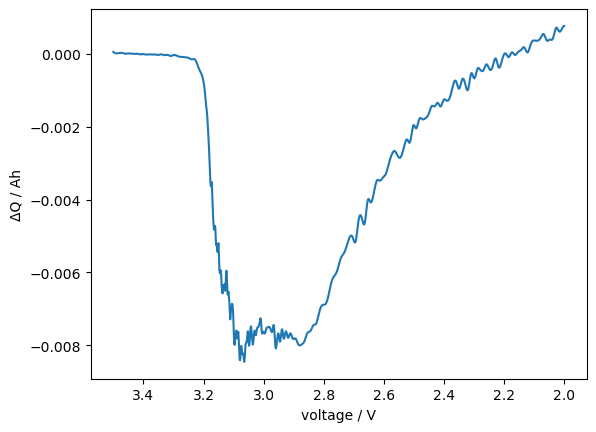

In [62]:
plt.plot(vd, delta_Q)
plt.xlabel('voltage / V'); plt.ylabel('ΔQ / Ah')
plt.gca().invert_xaxis()
plt.show()

### Reading the plot

X-axis is voltage, from 3.5 V (start of discharge) on the left to 2.0 V (empty) on the right.

Y-axis is capacity difference, in Ah. Negative means the cell delivered less at cycle 100 than at cycle 10.

Now trace it:

3.5 → 3.2 V: flat at zero. No loss here. Early in the discharge, cycle 100 behaves identically to cycle 10.

3.2 → 3.1 V: falls off a cliff. Drops from 0 to −0.008 over about 0.1 V. Something specific happens right here.

3.1 → 2.8 V: bottom, around −0.008. The loss is at its maximum.

2.8 → 2.0 V: climbs back toward zero. Ends near +0.0008.
### What the shape means

The right-hand end is the key. By 2.0 V the curve has nearly returned to zero — meaning total capacity barely changed between cycle 10 and cycle 100. Which matches your summary table: 1.0745 → 1.0738.

If you'd only looked at total capacity you'd conclude nothing happened.

But something did happen. The cell lost 0.008 Ah in the 3.25–2.8 V window and got it back lower down. Capacity moved rather than disappeared — it now comes out at lower voltages than it used to.

That's degradation you'd never see in the summary numbers. It's the whole reason this feature exists.

### Feature engineered Delta Q done for all the batteries in the 3 batches

In [63]:
def var_dq_feature(f, batch, label):
    rows = []
    Vdlin = f[batch['Vdlin'][0, 0]][()].ravel()

    for i in range(batch['summary'].shape[0]):
        c = f[batch['cycles'][i, 0]]
        n = c['Qdlin'].shape[0]

        if n < 100:                      # cell died before cycle 100
            rows.append({'cell_id': f'{label}c{i}', 'log_var_dQ': np.nan})
            continue

        q10  = f[c['Qdlin'][9,  0]][()].ravel()
        q100 = f[c['Qdlin'][99, 0]][()].ravel()
        dq = q100 - q10

        rows.append({
            'cell_id':    f'{label}c{i}',
            'log_var_dQ': np.log10(np.var(dq)),
            'min_dQ':     dq.min(),
        })
    return pd.DataFrame(rows).set_index('cell_id')

feature = pd.concat([
    var_dq_feature(f1, batch1, 'b1'),
    var_dq_feature(f2, batch2, 'b2'),
    var_dq_feature(f3, batch3, 'b3'),
])
print(feature.shape)
feature.head()

(140, 2)


,log_var_dQ,min_dQ
cell_id,,
b1c0,-5.014861,-0.008460
b1c1,-5.013960,-0.011004
b1c2,-4.737000,-0.017216
b1c3,-4.442613,-0.018961
b1c4,-4.647744,-0.013958


In [64]:
df = clean_df.join(feature)
df['log_life'] = np.log10(df.cycle_life) #The feature is already logged. Comparing a logged feature to an unlogged cycle gives a curved relationship. Logging both makes it straight.
df.head()

,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last,batch,log_var_dQ,min_dQ,log_life
cell_id,,,,,,,,,,,
b1c5,4.4C(80%)-4.4C,1074.0,1073,1.077600,0.880536,0.016359,0.019527,1,-4.178878,-0.025179,3.031004
b1c6,4.8C(80%)-4.8C,636.0,635,1.078115,0.880057,0.016926,0.020405,1,-3.768878,-0.037886,2.803457
b1c7,4.8C(80%)-4.8C,870.0,869,1.095673,0.881106,0.016241,0.019942,1,-3.813486,-0.038233,2.939519
b1c9,5.4C(40%)-3.6C,1054.0,1053,1.084173,0.880928,0.016927,0.020327,1,-4.059384,-0.028724,3.022841
b1c11,5.4C(50%)-3C,788.0,787,1.055643,0.880544,0.016556,0.019324,1,-4.146897,-0.023692,2.896526


In [65]:
df.shape

(123, 11)

#### Deciding factor: whether to use logged cycle_life or the raw cycle life

r = -0.905  r² = 0.818


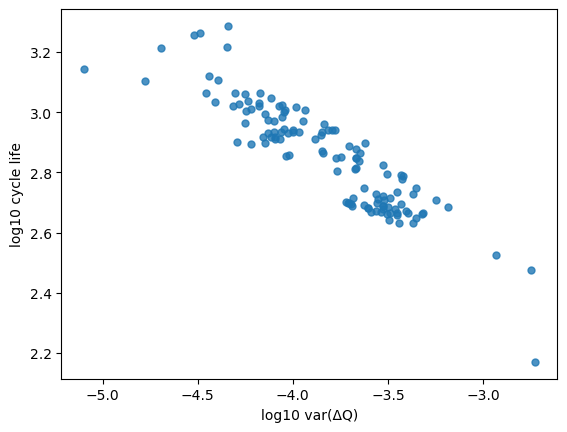

In [66]:
r = df[['log_var_dQ', 'log_life']].dropna().corr().iloc[0, 1]
print("r =", round(r, 3), " r² =", round(r**2, 3))

plt.scatter(df.log_var_dQ, df.log_life, s=25, alpha=0.8)
plt.xlabel('log10 var(ΔQ)'); plt.ylabel('log10 cycle life')
plt.show()

r = -0.867  r² = 0.751


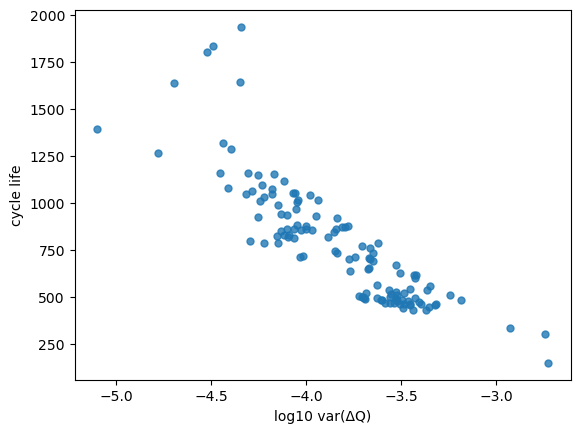

In [67]:
r = df[['log_var_dQ', 'cycle_life']].dropna().corr().iloc[0, 1]
print("r =", round(r, 3), " r² =", round(r**2, 3))

plt.scatter(df.log_var_dQ, df.cycle_life, s=25, alpha=0.8)
plt.xlabel('log10 var(ΔQ)'); plt.ylabel('cycle life')
plt.show()

In [68]:
d = df[['log_var_dQ','cycle_life','log_life']].dropna()
bins = pd.cut(d.log_var_dQ, 4)
tab = d.groupby(bins, observed=True)[['cycle_life','log_life']].agg(['mean','std'])
tab[('cycle_life','CV')] = tab[('cycle_life','std')] / tab[('cycle_life','mean')]
print(tab.round(3))

                 cycle_life          log_life        cycle_life
                       mean      std     mean    std         CV
log_var_dQ                                                     
(-5.101, -4.506]   1524.000  240.645    3.179  0.069      0.158
(-4.506, -3.913]   1017.708  249.269    2.997  0.092      0.245
(-3.913, -3.32]     587.262  138.260    2.758  0.096      0.235
(-3.32, -2.727]     373.000  138.770    2.538  0.203      0.372


### Dropping b3c37 as per the paper

### Extra EDA step:
**This check is done as the paper excluded this cell (b3c37) for measurement noise. That's the lowest variance in the dataset — meaning almost no change between cycle 10 and cycle 100 and it lived 1,390 cycles.**

In [69]:
from scipy import stats

df['z_var_dQ'] = stats.zscore(df.log_var_dQ, nan_policy='omit')
print(df.loc[df.z_var_dQ.abs() > 3,
                   ['policy', 'cycle_life', 'log_var_dQ', 'z_var_dQ']])

                              policy  cycle_life  log_var_dQ  z_var_dQ
cell_id                                                               
b3c37    4.8C(80%)-4.8C-newstructure      1390.0   -5.098856 -3.218829


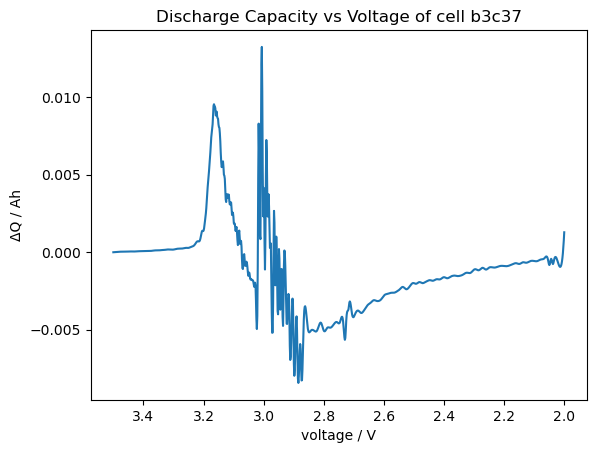

In [70]:
i = 37
c3 = f3[batch3['cycles'][i, 0]]
q10  = f3[c3['Qdlin'][9,  0]][()].ravel()
q100 = f3[c3['Qdlin'][99, 0]][()].ravel()
plt.plot(vd, q100 - q10)
plt.gca().invert_xaxis()
plt.xlabel('voltage / V')
plt.ylabel('ΔQ / Ah') 
plt.title('Discharge Capacity vs Voltage of cell b3c37')
plt.show()

The plot shows that this cell is a bad measurement and would add up to the noise in the model. This one:

- Spikes to +0.013 at 3.2 V. Positive means the cell delivered more capacity at cycle 100 than at cycle 10 — at that voltage, a gain of over 1% of total capacity. Cells don't gain capacity.
- Violent oscillation between 3.1 and 2.8 V. Swings from +0.013 to −0.008 and back, repeatedly, over a few hundredths of a volt (Real electrochem doesn't reverse direction dozens of times in that span)
- A spike at 2.0 V, right at the end.

In [71]:
clean_df = df.drop(index='b3c37')
clean_df.shape

(122, 12)

### 3.2. Feature 2 - ir_delta: Internal resistance *growth* over the first 100 cycles should track interface growth directly 
As a cell ages, the SEI layer on the graphite thickens. Thicker layer, more resistance to lithium crossing it, higher measured resistance. A cell whose interface is degrading quickly should show resistance rising quickly — so ir_delta should be a leading indicator of short life.`ir_delta` is expected to be positive for every cell, larger for cells that die sooner. 

In [72]:
def ir_features(f, batch, label):
    rows = []
    for i in range(batch['summary'].shape[0]):
        s = f[batch['summary'][i, 0]]
        ir = np.asarray(s['IR']).ravel()
        if len(ir) < 100:
            rows.append({'cell_id': f'{label}c{i}'})
            continue
        rows.append({
            'cell_id':  f'{label}c{i}',
            'ir_delta': ir[95:100].mean() - ir[5:10].mean(),
        })
    return pd.DataFrame(rows).set_index('cell_id')

ir_feat = pd.concat([
    ir_features(f1, batch1, 'b1'),
    ir_features(f2, batch2, 'b2'),
    ir_features(f3, batch3, 'b3'),
])
print(ir_feat.shape)
print(ir_feat.ir_delta.describe())

(140, 1)
count    140.000000
mean      -0.000011
std        0.000391
min       -0.003986
25%       -0.000071
50%        0.000040
75%        0.000143
max        0.000510
Name: ir_delta, dtype: float64


In [73]:
clean_df = clean_df.join(ir_feat)
print(clean_df.shape)
print(clean_df.ir_delta.isna().sum())
clean_df.head()

(122, 13)
0


,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last,batch,log_var_dQ,min_dQ,log_life,z_var_dQ,ir_delta
cell_id,,,,,,,,,,,,,
b1c5,4.4C(80%)-4.4C,1074.0,1073,1.077600,0.880536,0.016359,0.019527,1,-4.178878,-0.025179,3.031004,-0.895266,0.000056
b1c6,4.8C(80%)-4.8C,636.0,635,1.078115,0.880057,0.016926,0.020405,1,-3.768878,-0.037886,2.803457,0.140261,-0.000091
b1c7,4.8C(80%)-4.8C,870.0,869,1.095673,0.881106,0.016241,0.019942,1,-3.813486,-0.038233,2.939519,0.027595,0.000093
b1c9,5.4C(40%)-3.6C,1054.0,1053,1.084173,0.880928,0.016927,0.020327,1,-4.059384,-0.028724,3.022841,-0.593462,0.000067
b1c11,5.4C(50%)-3C,788.0,787,1.055643,0.880544,0.016556,0.019324,1,-4.146897,-0.023692,2.896526,-0.814491,-0.000064


In [74]:
print("negative:", (clean_df.ir_delta < 0).sum(), "of", len(clean_df))
print(clean_df.ir_delta.describe())

negative: 53 of 122
count    122.000000
mean      -0.000033
std        0.000411
min       -0.003986
25%       -0.000091
50%        0.000027
75%        0.000141
max        0.000389
Name: ir_delta, dtype: float64


Before testing against the target, ir_delta fails a basic physical sanity check: 43% of cells show decreasing resistance. This is the first indication the feature is noise-limited.

### 3.3. Feature 3 - Slope of battery degradation between cycle 2 and cycle 100 plotting there discharge capacity for the 99 cycles

In [109]:
for i in [5, 6]:
    s = f1[batch1['summary'][i,0]]
    qd = np.asarray(s['QDischarge']).ravel()
    cl = clean_df.loc[f'b1c{i}', 'cycle_life'] if f'b1c{i}' in clean_df.index else 'excluded'
    print(f"index {i} → b1c{i}: cycle_life {cl}, Q@2 {qd[1]:.4f}, Q@100 {qd[99]:.4f}")

index 5 → b1c5: cycle_life 1074.0, Q@2 1.0761, Q@100 1.0798
index 6 → b1c6: cycle_life 636.0, Q@2 1.0758, Q@100 1.0792


In [ ]:
i = 5                   #cell 5 b1c5 as the b1c0- b1c4 removed during cleaning
s = f1[batch1['summary'][i, 0]]
qd = np.asarray(s['QDischarge']).ravel()

cycle_col = np.asarray(s['cycle']).ravel()
cycles = cycle_col[1:100]
capacity = qd[1:100]

print(len(cycles), len(capacity))
print(capacity[:5])
print(capacity[-5:])

99 99
[1.0761266 1.0766531 1.0775996 1.0785232 1.0790976]
[1.0798595 1.079825  1.0797906 1.0797876 1.0797794]


In [76]:
slopes = []
for i in range(batch1['summary'].shape[0]):
    s = f1[batch1['summary'][i, 0]]
    qd = np.asarray(s['QDischarge']).ravel()
    if len(qd) < 100: continue
    cyc = np.asarray(s['cycle']).ravel()[1:100]
    res = stats.linregress(cyc, qd[1:100])
    slopes.append({'cell': f'b1c{i}', 'slope': res.slope, 'fit_r2': res.rvalue**2})

sl = pd.DataFrame(slopes)
print(sl.fit_r2.describe())
print("cells with positive slope:", (sl.slope > 0).sum(), "of", len(sl))

count    46.000000
mean      0.202461
std       0.222334
min       0.000036
25%       0.026004
50%       0.147255
75%       0.266299
max       0.920559
Name: fit_r2, dtype: float64
cells with positive slope: 19 of 46


At cycle 100 the capacity trend does not yet exist as a measurable quantity. A linear fit of discharge capacity against cycle number over cycles 2–100 explains a median of only 15% of the variation, and under 3% for the lowest quartile. 19 of 46 batch-1 cells return a positive slope, indicating that what the fit captures is the formation/break-in rise rather than degradation. In simple terms, the slope is positive which means the battery is not losing any capayity by the 100th cycle. Instead it is gaining small capacity because of the breakin process which happens at the beginning in electrochemical cells. 
**The feature is rejected before testing against the target: the quantity it claims to measure has not yet emerged at cycle 100.**

### 3.4. Feature 4 -  Higher moments of dQ(V)

In [77]:
def dq_stats(f, batch, label):
    rows = []
    for i in range(batch['summary'].shape[0]):
        c = f[batch['cycles'][i, 0]]
        if c['Qdlin'].shape[0] < 100:
            rows.append({'cell_id': f'{label}c{i}'}); continue
        dq = f[c['Qdlin'][99,0]][()].ravel() - f[c['Qdlin'][9,0]][()].ravel()
        rows.append({
            'cell_id':  f'{label}c{i}',
            'dq_skew':  stats.skew(dq),
            'dq_kurt':  stats.kurtosis(dq),
            'dq_mean':  np.log10(np.abs(dq.mean())),
        })
    return pd.DataFrame(rows).set_index('cell_id')

dqs = pd.concat([dq_stats(f1, batch1, 'b1'),
                 dq_stats(f2, batch2, 'b2'),
                 dq_stats(f3, batch3, 'b3')])

clean_df = clean_df.drop(columns=['dq_skew','dq_kurt','dq_mean'], errors='ignore')
clean_df = clean_df.join(dqs)

print(clean_df[['log_var_dQ','dq_skew','dq_kurt','dq_mean']].corr().round(2))

            log_var_dQ  dq_skew  dq_kurt  dq_mean
log_var_dQ        1.00     0.25    -0.28     0.92
dq_skew           0.25     1.00     0.77    -0.02
dq_kurt          -0.28     0.77     1.00    -0.57
dq_mean           0.92    -0.02    -0.57     1.00


In [78]:
print(clean_df.batch.value_counts().sort_index())

batch
1    36
2    43
3    43
Name: count, dtype: int64


### 3.5. Feature 5 -  Charging protocol parameters

Each policy string such as `4.4C(80%)-5C` encodes first-stage rate, the state of
charge at which the rate switches, and second-stage rate. Four further quantities
are derived from those three.

In [79]:
import re

def parse_policy(p):
    p = str(p).replace('-newstructure', '')
    m = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', p)
    if not m:
        return pd.Series({'c1': np.nan, 'soc_switch': np.nan, 'c2': np.nan})
    return pd.Series({'c1': float(m.group(1)),
                      'soc_switch': float(m.group(2)),
                      'c2': float(m.group(3))})

pol = clean_df.policy.apply(parse_policy)
print("failed to parse:", pol.c1.isna().sum(), "of", len(pol))
print(pol.describe().round(2))

failed to parse: 1 of 122
           c1  soc_switch      c2
count  121.00      121.00  121.00
mean     5.33       43.61    4.25
std      1.14       22.40    0.83
min      1.00        2.00    3.00
25%      4.80       25.00    3.60
50%      5.40       40.00    4.25
75%      5.90       60.00    4.80
max      8.00       80.00    6.00


In [80]:
pol['c_avg']    = (pol.c1*pol.soc_switch + pol.c2*(80 - pol.soc_switch)) / 80
pol['c_max']    = pol[['c1','c2']].max(axis=1)
pol['c_step']   = pol.c1 - pol.c2
pol['charge_t'] = pol.soc_switch/pol.c1 + (80 - pol.soc_switch)/pol.c2

clean_df = clean_df.join(pol)
print(list(pol.columns))

['c1', 'soc_switch', 'c2', 'c_avg', 'c_max', 'c_step', 'charge_t']


In [81]:
clean_df.head()

,policy,cycle_life,n_cycles,Q_initial,Q_last,IR_initial,IR_last,batch,log_var_dQ,min_dQ,...,dq_skew,dq_kurt,dq_mean,c1,soc_switch,c2,c_avg,c_max,c_step,charge_t
cell_id,,,,,,,,,,,,,,,,,,,,,
b1c5,4.4C(80%)-4.4C,1074.0,1073,1.077600,0.880536,0.016359,0.019527,1,-4.178878,-0.025179,...,-0.149350,-1.227527,-1.955699,4.4,80.0,4.4,4.4,4.4,0.0,18.181818
b1c6,4.8C(80%)-4.8C,636.0,635,1.078115,0.880057,0.016926,0.020405,1,-3.768878,-0.037886,...,-0.407936,-1.238070,-1.796830,4.8,80.0,4.8,4.8,4.8,0.0,16.666667
b1c7,4.8C(80%)-4.8C,870.0,869,1.095673,0.881106,0.016241,0.019942,1,-3.813486,-0.038233,...,-0.333417,-1.120536,-1.778697,4.8,80.0,4.8,4.8,4.8,0.0,16.666667
b1c9,5.4C(40%)-3.6C,1054.0,1053,1.084173,0.880928,0.016927,0.020327,1,-4.059384,-0.028724,...,-0.427591,-1.182171,-1.938902,5.4,40.0,3.6,4.5,5.4,1.8,18.518519
b1c11,5.4C(50%)-3C,788.0,787,1.055643,0.880544,0.016556,0.019324,1,-4.146897,-0.023692,...,-0.594848,-1.205555,-2.076849,5.4,50.0,3.0,4.5,5.4,2.4,19.259259


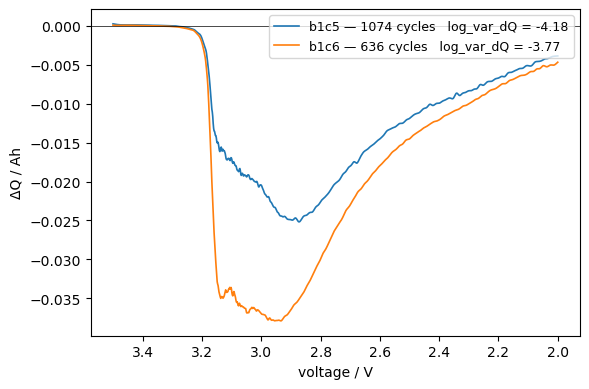

In [111]:
vdlin = np.asarray(f1[batch1['Vdlin'][0,0]]).ravel()
fig, ax = plt.subplots(figsize=(6,4))
for cid, i, lab in [('b1c5', 5, 'b1c5 — 1074 cycles'), ('b1c6', 6, 'b1c6 — 636 cycles')]:
    c = f1[batch1['cycles'][i,0]]
    dq = f1[c['Qdlin'][99,0]][()].ravel() - f1[c['Qdlin'][9,0]][()].ravel()
    ax.plot(vdlin, dq, lw=1.2, label=f"{lab}   log_var_dQ = {clean_df.loc[cid,'log_var_dQ']:.2f}")
ax.invert_xaxis(); ax.axhline(0, c='k', lw=0.5)
ax.set_xlabel('voltage / V'); ax.set_ylabel('ΔQ / Ah'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

batch                1      2      3
log_var_dQ mean -3.791 -3.474 -4.173
           std   0.233  0.238  0.260
           min  -4.179 -4.034 -4.779
           max  -3.350 -2.727 -3.452
Q_initial  mean  1.080  1.072  1.065
           std   0.008  0.007  0.007
           min   1.056  1.043  1.047
           max   1.096  1.084  1.075
log_life   mean  2.889  2.667  3.006
           std   0.082  0.094  0.118
           min   2.728  2.170  2.733
           max   3.031  2.853  3.287


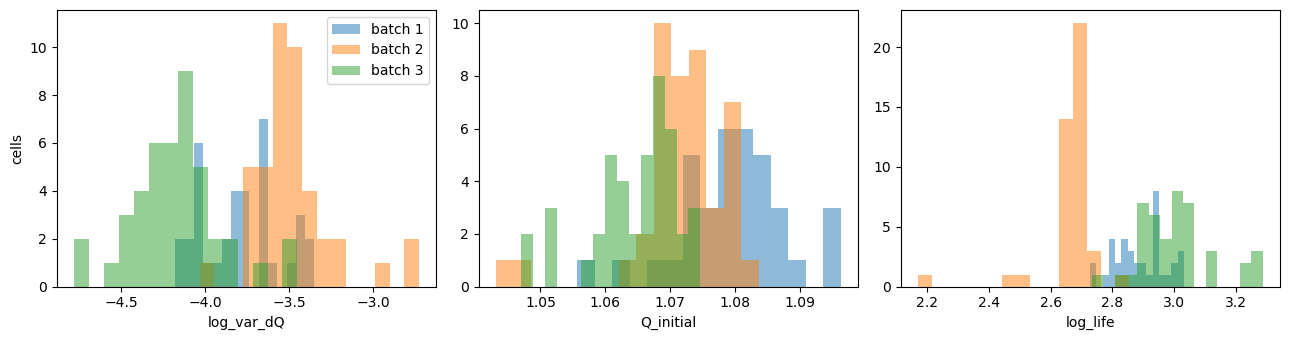

In [82]:
cols = ['log_var_dQ', 'Q_initial', 'log_life']
print(clean_df.groupby('batch')[cols].agg(['mean','std','min','max']).round(3).T)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for a, col in zip(ax, cols):
    for b, grp in clean_df.groupby('batch'):
        a.hist(grp[col].dropna(), bins=15, alpha=0.5, label=f'batch {b}')
    a.set_xlabel(col)
ax[0].set_ylabel('cells') 
ax[0].legend()
plt.tight_layout() 
plt.show()

# Ex: 1- Train test split done on batch 1 and 2. Validation done on batch 3.
**Ex 1.1- X contains only 1 feature coulmn**

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [84]:
SEED = 42
dev = clean_df[clean_df.batch.isin([1, 2])].copy()   # Batch 1 and 2 
sec = clean_df[clean_df.batch == 3].copy()           # Batch 3 is the secondary (sealed) batch. It is used to test the model trained on the development batch.
print(f"development: {len(dev)}   secondary (sealed): {len(sec)}")

development: 79   secondary (sealed): 43


In [85]:
combos = {
    'log_var_dQ':                   ['log_var_dQ'],
    '+ Q_initial':                  ['log_var_dQ', 'Q_initial'],
    '+ min_dQ':                     ['log_var_dQ', 'min_dQ'],
    '+ IR_initial':                 ['log_var_dQ', 'IR_initial'],
    '+ ir_delta':                   ['log_var_dQ', 'ir_delta'],
    '+ dq_skew':                    ['log_var_dQ', 'dq_skew'],
    '+ dq_kurt':                    ['log_var_dQ', 'dq_kurt'],
    '+ Q_initial + IR_initial':     ['log_var_dQ', 'Q_initial', 'IR_initial'],
    '+ Q_initial + ir_delta':       ['log_var_dQ', 'Q_initial', 'ir_delta'],
}

rows = []
for label, cols in combos.items():
    d = dev[cols + ['log_life']]
    Xtr, Xte, ytr, yte = train_test_split(d[cols], d.log_life,
                                          test_size=0.3, random_state=SEED)
    m = LinearRegression().fit(Xtr, ytr)
    rows.append({
        'features':  label,
        'n':         len(d),
        'train_r2':  r2_score(ytr, m.predict(Xtr)),
        'test_r2':   r2_score(yte, m.predict(Xte)),
        'test_MAPE': mean_absolute_percentage_error(10**yte, 10**m.predict(Xte)) * 100,
    })

res = pd.DataFrame(rows).round(3)
res['gap']    = (res.train_r2 - res.test_r2).round(3)
res['change'] = (res.test_r2 - res.test_r2.iloc[0]).round(3)
print(res.to_string(index=False))

                features  n  train_r2  test_r2  test_MAPE   gap  change
              log_var_dQ 79     0.764    0.674     13.653 0.090   0.000
             + Q_initial 79     0.818    0.764     11.574 0.054   0.090
                + min_dQ 79     0.765    0.677     13.844 0.088   0.003
            + IR_initial 79     0.842    0.525     12.295 0.317  -0.149
              + ir_delta 79     0.785    0.065     16.041 0.720  -0.609
               + dq_skew 79     0.767    0.674     14.061 0.093   0.000
               + dq_kurt 79     0.764    0.676     13.707 0.088   0.002
+ Q_initial + IR_initial 79     0.856    0.665     10.545 0.191  -0.009
  + Q_initial + ir_delta 79     0.820    0.607     13.154 0.213  -0.067


Screening result

Only Q_initial improves on the baseline: test r² rises 0.674 → 0.764 and the train–test gap narrows from 0.090 to 0.054. Adding a feature that both improves generalisation and reduces overfitting indicates real signal rather than fitted noise.

The rest are rejected, each consistent with the diagnostics computed during feature engineering:

ir_delta — test r² 0.065 against train 0.785, a gap of 0.720. The 43% of cells with physically impossible negative values now show their effect directly: the model fits noise in the training cells and carries nothing to new ones.
IR_initial — test r² falls to 0.525 while train rises to 0.842. Same noise-limited measurement, same failure mode.
min_dQ, dq_skew, dq_kurt — all within ±0.003 of baseline, consistent with their correlations against log_var_dQ (−0.94, 0.25, −0.28). No information the variance does not already carry.

Carried forward: log_var_dQ and Q_initial.

The charging-protocol parameters are screened separately below. They are six columns that only make sense as a block — testing them one at a time would be meaningless, since c1 alone does not describe a protocol.

In [86]:
POLICY = ['c1','soc_switch','c2','c_avg','c_max','charge_t']

combos2 = {
    'log_var_dQ':                        ['log_var_dQ'],
    'log_var_dQ + Q_initial':            ['log_var_dQ','Q_initial'],
    'policy only':                       POLICY,
    'log_var_dQ + policy':               ['log_var_dQ'] + POLICY,
    'log_var_dQ + Q_initial + policy':   ['log_var_dQ','Q_initial'] + POLICY,
}

rows = []
for label, cols in combos2.items():
    d = dev[cols + ['log_life']].dropna()
    Xtr, Xte, ytr, yte = train_test_split(d[cols], d.log_life,
                                          test_size=0.3, random_state=SEED)
    m = LinearRegression().fit(Xtr, ytr)
    rows.append({'features': label, 'n': len(d), 'n_feat': len(cols),
                 'train_r2': r2_score(ytr, m.predict(Xtr)),
                 'test_r2':  r2_score(yte, m.predict(Xte)),
                 'test_MAPE': mean_absolute_percentage_error(10**yte, 10**m.predict(Xte))*100})

res2 = pd.DataFrame(rows).round(3)
res2['gap'] = (res2.train_r2 - res2.test_r2).round(3)
print(res2.to_string(index=False))

                       features  n  n_feat  train_r2  test_r2  test_MAPE    gap
                     log_var_dQ 79       1     0.764    0.674     13.653  0.090
         log_var_dQ + Q_initial 79       2     0.818    0.764     11.574  0.054
                    policy only 78       6     0.586    0.625     15.290 -0.039
            log_var_dQ + policy 78       7     0.840    0.651     14.043  0.189
log_var_dQ + Q_initial + policy 78       8     0.872    0.743     11.763  0.129


On a single 70/30 split the charging-protocol features do not help: test r² falls from 0.764 to 0.743 and the train–test gap more than doubles, from 0.054 to 0.129. The policy only row shows a negative gap (−0.039), a small-sample artefact indicating that with 24 test cells this split is not a reliable instrument. Policy rows use 78 cells rather than 79 owing to one unparsed policy string.

Both feature sets are therefore carried into cross-validation rather than being decided here.

In [87]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge


In [88]:

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

POLICY   = ['c1','soc_switch','c2','c_avg','c_max','charge_t']
FEATS_1  = ['log_var_dQ']
FEATS_2  = ['log_var_dQ','Q_initial']
FEATS_8  = FEATS_2 + POLICY

feature_sets = {'1 feat': FEATS_1,
                '2 feat': FEATS_2,
                '8 feat (2 core + 6 policy)': FEATS_8}

models = {
    'Linear':   LinearRegression(),
    'Ridge':    Ridge(alpha=1.0),
    'RF':       RandomForestRegressor(n_estimators=300, random_state=SEED),
    'GradBoost':GradientBoostingRegressor(random_state=SEED),
}

rows = []
for fname, cols in feature_sets.items():
    d = dev[cols + ['log_life']].dropna()
    for mname, mdl in models.items():
        cv = cross_validate(make_pipeline(StandardScaler(), mdl),
                            d[cols], d.log_life, cv=kf,
                            scoring='r2', return_train_score=True)
        rows.append({'model': mname, 'features': fname, 'n': len(d),
                     'train_r2': cv['train_score'].mean(),
                     'cv_r2':    cv['test_score'].mean(),
                     'cv_std':   cv['test_score'].std()})

cvres = pd.DataFrame(rows).round(3)
cvres['gap'] = (cvres.train_r2 - cvres.cv_r2).round(3)
print(cvres.sort_values('cv_r2', ascending=False).to_string(index=False))

    model                   features  n  train_r2  cv_r2  cv_std   gap
GradBoost 8 feat (2 core + 6 policy) 78     0.999  0.810   0.051 0.189
       RF 8 feat (2 core + 6 policy) 78     0.967  0.801   0.082 0.166
       RF                     2 feat 79     0.970  0.796   0.062 0.174
GradBoost                     2 feat 79     0.997  0.794   0.042 0.203
   Linear 8 feat (2 core + 6 policy) 78     0.868  0.783   0.063 0.085
    Ridge 8 feat (2 core + 6 policy) 78     0.867  0.782   0.057 0.085
    Ridge                     2 feat 79     0.810  0.748   0.082 0.062
   Linear                     2 feat 79     0.810  0.746   0.083 0.064
       RF                     1 feat 79     0.963  0.706   0.111 0.257
GradBoost                     1 feat 79     0.990  0.687   0.122 0.303
    Ridge                     1 feat 79     0.748  0.662   0.117 0.086
   Linear                     1 feat 79     0.748  0.660   0.121 0.088


Cross-validation reverses the single-split result. The charging-protocol features improve the linear model from 0.746 to 0.783, where the single split had shown a decline to 0.743 — confirming that one 70/30 partition of 79 cells is too noisy to select features on.

Tree ensembles post the highest cross-validated scores (GradBoost 0.810, RF 0.801) but with train r² of 0.999 and 0.967 and train–test gaps of 0.166–0.189, against 0.085 for the linear model. The separation is by model family: every tree configuration gaps 0.166–0.303, every linear and Ridge configuration 0.062–0.088. The 0.027 advantage in mean score is smaller than the fold-to-fold standard deviation of either model.

Ridge performs identically to unregularised linear regression, indicating the linear model is not overfitting and has nothing for regularisation to correct.

Whether the trees' memorisation of the training set costs them on genuinely unseen data is the question the sealed batch-3 evaluation answers.

In [89]:
from sklearn.model_selection import GridSearchCV

d = dev[FEATS_8 + ['log_life']].dropna()
grid = {'gradientboostingregressor__n_estimators': [100, 300],
        'gradientboostingregressor__max_depth': [2, 3],
        'gradientboostingregressor__learning_rate': [0.05, 0.1],
        'gradientboostingregressor__min_samples_leaf': [1, 3]}

gs = GridSearchCV(make_pipeline(StandardScaler(), GradientBoostingRegressor(random_state=SEED)),
                  grid, cv=kf, scoring='r2').fit(d[FEATS_8], d.log_life)
print(f"best CV r²: {gs.best_score_:.3f}")
print(gs.best_params_)

best CV r²: 0.810
{'gradientboostingregressor__learning_rate': 0.05, 'gradientboostingregressor__max_depth': 3, 'gradientboostingregressor__min_samples_leaf': 1, 'gradientboostingregressor__n_estimators': 300}


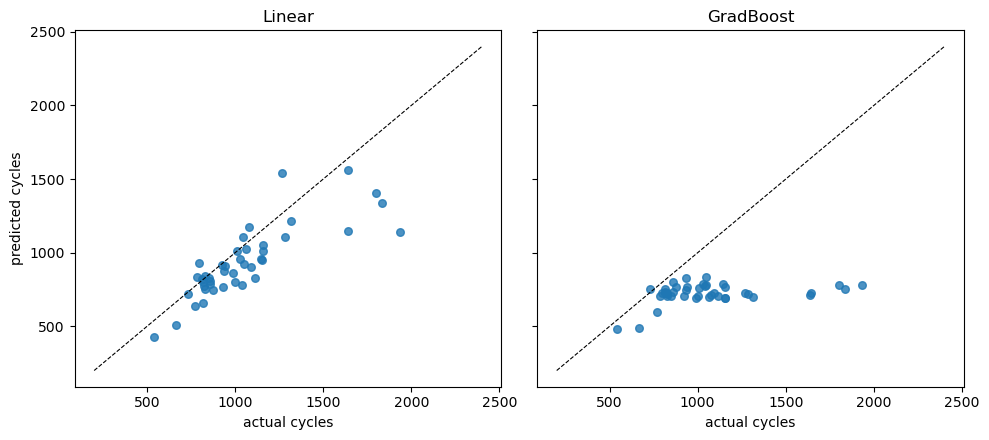

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

for a, mname in zip(ax, ['Linear', 'GradBoost']):
    cols = FEATS_8
    d_dev = dev[cols + ['log_life']].dropna()
    d_sec = sec[cols + ['log_life']].dropna()
    p = make_pipeline(StandardScaler(), models[mname]).fit(d_dev[cols], d_dev.log_life)
    pred = p.predict(d_sec[cols])

    a.scatter(10**d_sec.log_life, 10**pred, s=30, alpha=0.8)
    lims = [200, 2400]
    a.plot(lims, lims, 'k--', lw=0.8)
    a.set_xlabel('actual cycles'); a.set_title(mname)
ax[0].set_ylabel('predicted cycles')
plt.tight_layout(); plt.show()

In [91]:
rows = []
for fname, cols in feature_sets.items():
    d_dev = dev[cols + ['log_life']].dropna()
    d_sec = sec[cols + ['log_life']].dropna()
    for mname, mdl in models.items():
        pipe = make_pipeline(StandardScaler(), mdl).fit(d_dev[cols], d_dev.log_life)
        pred = pipe.predict(d_sec[cols])
        rows.append({'model': mname, 'features': fname,
                     'n_dev': len(d_dev), 'n_sec': len(d_sec),
                     'sec_r2':   r2_score(d_sec.log_life, pred),
                     'sec_MAPE': mean_absolute_percentage_error(
                                     10**d_sec.log_life, 10**pred) * 100})

secres = pd.DataFrame(rows).round(3)
print(secres.sort_values('sec_r2', ascending=False).to_string(index=False))

    model                   features  n_dev  n_sec  sec_r2  sec_MAPE
    Ridge                     1 feat     79     43   0.590    12.968
   Linear                     1 feat     79     43   0.585    13.237
   Linear 8 feat (2 core + 6 policy)     78     43   0.557    12.738
   Linear                     2 feat     79     43   0.499    12.909
    Ridge                     2 feat     79     43   0.483    13.153
    Ridge 8 feat (2 core + 6 policy)     78     43   0.458    14.166
GradBoost                     1 feat     79     43   0.259    15.374
       RF                     1 feat     79     43   0.080    17.043
GradBoost                     2 feat     79     43  -0.319    19.406
       RF                     2 feat     79     43  -0.426    19.280
       RF 8 feat (2 core + 6 policy)     78     43  -0.978    23.794
GradBoost 8 feat (2 core + 6 policy)     78     43  -1.389    26.919


Sealed evaluation on batch 3

The cross-validation ranking inverts completely. GradBoost with eight features ranked first on the development set (cv r² 0.810) and last on batch 3 (r² −1.389). Every linear and Ridge configuration remains positive; every tree configuration is negative except the two single-feature cases.

A negative r² means the model performs worse than predicting the training mean. The trees did not degrade — they inverted.

The mechanism is extrapolation. A tree predicts by averaging the training samples that fall in a leaf, so beyond the training range it returns the nearest leaf's average: a flat, constant answer. Batch 3 sits systematically outside the batch-1/2 feature range, so tree predictions collapse toward a horizontal line. A linear model continues its fitted slope instead; the extrapolation may be inaccurate, but it still tracks the direction of the relationship.

Adding features makes the trees monotonically worse (RF: 0.080 → −0.426 → −0.978), since each additional dimension is another axis along which batch 3 lies outside the training range.

Within the linear family the ranking is nearly flat: one feature gives the best r² (0.585) and eight features the best MAPE (12.74% against 13.24%). The charging-protocol features improve fit within a production run and give back a little across runs.

The train–test gap was the reliable warning, not the cross-validated mean. Every tree configuration gapped 0.166–0.303 while every linear configuration gapped 0.062–0.088, and that separation predicted the outcome where the mean score did not.

# Ex-2 Split train test data by from all 3 batches

In [92]:
all_dev = clean_df.copy()
X_all = all_dev[['log_var_dQ','Q_initial']]
y_all = all_dev['log_life']

In [93]:

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X_all, y_all,
                                              test_size=0.3, random_state=SEED)
print(Xa_tr.shape, Xa_te.shape)

for name, mdl in models.items():
    pipe = make_pipeline(StandardScaler(), mdl).fit(Xa_tr, ya_tr)
    pred = pipe.predict(Xa_te)
    print(f"{name:10s} train r² {r2_score(ya_tr, pipe.predict(Xa_tr)):.3f}   "
          f"test r² {r2_score(ya_te, pred):.3f}   "
          f"MAPE {mean_absolute_percentage_error(10**ya_te, 10**pred)*100:.2f}%")

(85, 2) (37, 2)
Linear     train r² 0.863   test r² 0.822   MAPE 11.81%
Ridge      train r² 0.863   test r² 0.827   MAPE 11.70%
RF         train r² 0.978   test r² 0.787   MAPE 12.62%
GradBoost  train r² 0.996   test r² 0.709   MAPE 12.54%


The linear models now lead outright. On the equivalent split of the development set in Experiment 1, the tree ensembles were competitive; pooling all three batches did not simply raise every score, it changed the ranking.

The train–test gaps separate by model family exactly as before: 0.036 and 0.041 for Linear and Ridge against 0.191 and 0.287 for RF and GradBoost. GradBoost reaches a train r² of 0.996 and the worst test score in the table — it has memorised the 85 training cells.

Ridge and Linear differ by 0.005 in test r², which is within the noise of a single 37-cell test partition. That regularisation changes nothing indicates the linear model has no overfitting to correct, consistent with its small gap.

This is one partition and should be read as orientation only. The cross-validated results below are the basis for any conclusion.

In [94]:
from sklearn.model_selection import cross_val_score
kf_all  = KFold(n_splits=5, shuffle=True, random_state=SEED)
combos = {
    'log_var_dQ':              ['log_var_dQ'],
    'Q_initial':               ['Q_initial'],
    'policy (6)':              POLICY,
    'log_var_dQ + Q_initial':  FEATS_2,
    'log_var_dQ + policy':     ['log_var_dQ'] + POLICY,
    'all 8':                   FEATS_8,
}

for label, cols in combos.items():
    d = all_dev[cols + ['log_life']].dropna()
    s = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                        d[cols], d.log_life, cv=kf_all, scoring='r2')
    print(f"{label:24s} n={len(d)}  CV r² {s.mean():.3f} ± {s.std():.3f}")

log_var_dQ               n=122  CV r² 0.810 ± 0.027
Q_initial                n=122  CV r² -0.013 ± 0.029
policy (6)               n=121  CV r² 0.240 ± 0.190
log_var_dQ + Q_initial   n=122  CV r² 0.838 ± 0.040
log_var_dQ + policy      n=121  CV r² 0.828 ± 0.014
all 8                    n=121  CV r² 0.859 ± 0.017


In [95]:
rows = []
for fname, cols in feature_sets.items():
    d = all_dev[cols + ['log_life']].dropna()
    for mname, mdl in models.items():
        cv = cross_validate(make_pipeline(StandardScaler(), mdl),
                            d[cols], d.log_life, cv=kf_all,
                            scoring='r2', return_train_score=True)
        rows.append({'model': mname, 'features': fname, 'n': len(d),
                     'train_r2': cv['train_score'].mean(),
                     'cv_r2':    cv['test_score'].mean(),
                     'cv_std':   cv['test_score'].std()})

pooled = pd.DataFrame(rows).round(3)
pooled['gap'] = (pooled.train_r2 - pooled.cv_r2).round(3)
print(pooled.sort_values('cv_r2', ascending=False).to_string(index=False))

    model                   features   n  train_r2  cv_r2  cv_std   gap
    Ridge 8 feat (2 core + 6 policy) 121     0.894  0.861   0.016 0.033
   Linear 8 feat (2 core + 6 policy) 121     0.894  0.859   0.017 0.035
       RF 8 feat (2 core + 6 policy) 121     0.978  0.841   0.030 0.137
    Ridge                     2 feat 122     0.858  0.839   0.037 0.019
   Linear                     2 feat 122     0.859  0.838   0.040 0.021
       RF                     2 feat 122     0.978  0.816   0.058 0.162
    Ridge                     1 feat 122     0.830  0.810   0.025 0.020
   Linear                     1 feat 122     0.830  0.810   0.027 0.020
GradBoost 8 feat (2 core + 6 policy) 121     0.996  0.807   0.051 0.189
GradBoost                     2 feat 122     0.992  0.797   0.112 0.195
       RF                     1 feat 122     0.974  0.795   0.037 0.179
GradBoost                     1 feat 122     0.980  0.775   0.072 0.205


In [96]:
d = all_dev[FEATS_8 + ['log_life']].dropna()
p = make_pipeline(StandardScaler(), LinearRegression()).fit(d[FEATS_8], d.log_life)
print(pd.Series(p[-1].coef_, index=FEATS_8).round(3).sort_values(key=abs, ascending=False))

log_var_dQ   -0.187
Q_initial     0.034
c_max         0.033
soc_switch    0.026
c1           -0.019
c_avg         0.018
c2            0.015
charge_t      0.012
dtype: float64


Experiment 2 — pooled cross-validation, 122 cells

Linear and Ridge with eight features lead the table (cv r² 0.859 and 0.861), with train–test gaps of 0.035 and 0.033 and fold-to-fold standard deviations of 0.017 and 0.016 — the tightest of any configuration tested. Tree ensembles score below them with gaps of 0.137–0.205 and train r² of 0.974–0.996.

The separation by model family observed in Experiment 1 holds on the full dataset: every linear and Ridge configuration gaps 0.019–0.035, every tree configuration 0.137–0.205. This is a property of the model families on this data, not an artefact of the smaller development set.

Ridge matches unregularised linear regression to within 0.002 at every feature count, indicating the linear model has no overfitting for regularisation to correct.

The charging-protocol features are confirmed here: cv r² rises from 0.838 to 0.859 and the fold spread more than halves, from 0.040 to 0.017. The single 70/30 split in Experiment 1 had rejected them; five folds on 122 cells reverse that.

Relative to the development-set cross-validation in Experiment 1, every configuration improves and every fold spread tightens, reflecting 122 training cells rather than 79. This is not evidence that the pooled model generalises better. Pooling places batch-3 cells on both sides of every split, removing the distribution shift from the evaluation rather than from the problem. Experiment 1 remains the estimate of performance on an unseen production run; Experiment 2 estimates how much signal these features carry when training and deployment populations match.

GradBoost with eight features ranked first in Experiment 1's development cross-validation (0.810) and eighth here (0.807). Its ranking was never stable across evaluation designs.




# Neural Network approach

In [97]:
!pip install tensorflow

In [98]:
import tensorflow as tf
from tensorflow import keras

FEATS = ['log_var_dQ', 'Q_initial']

X_tr, X_te, y_tr, y_te = train_test_split(
    all_dev[FEATS], y_all, test_size=0.3, random_state=SEED)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

print(X_tr_s.shape, X_te_s.shape)

(85, 2) (37, 2)


In [99]:
tf.random.set_seed(42)
model = keras.Sequential([
    keras.layers.Input(shape=(len(FEATS),)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8,  activation='relu'),
    keras.layers.Dense(1)
])
model.compile(optimizer=keras.optimizers.Adam(0.01), loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [100]:
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_tr_s, y_tr, test_size=0.2, random_state=SEED)
print(f"train {X_tr2.shape[0]}   val {X_val.shape[0]}   test {X_te_s.shape[0]}")

es = keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True)
h = model.fit(X_tr2, y_tr2, validation_data=(X_val, y_val),
              epochs=500, batch_size=16, callbacks=[es], verbose=0)

print("stopped at epoch:", len(h.history['loss']))
for name, Xs, ys in [('train', X_tr2, y_tr2), ('val', X_val, y_val), ('test', X_te_s, y_te)]:
    pred = model.predict(Xs, verbose=0).ravel()
    print(f"{name:6s} r² {r2_score(ys, pred):.3f}  "
          f"MAPE {mean_absolute_percentage_error(10**ys, 10**pred)*100:.2f}%")

train 68   val 17   test 37
stopped at epoch: 312
train  r² 0.897  MAPE 11.29%
val    r² 0.866  MAPE 9.32%
test   r² 0.743  MAPE 14.35%


In [101]:
for seed in [0, 7, 42]:
    keras.backend.clear_session()
    tf.random.set_seed(seed)
    m = keras.Sequential([keras.layers.Input(shape=(len(FEATS),)),
                          keras.layers.Dense(16, activation='relu'),
                          keras.layers.Dense(8, activation='relu'),
                          keras.layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(0.01), loss='mse')
    m.fit(X_tr2, y_tr2, validation_data=(X_val, y_val), epochs=500,
          batch_size=16, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True)])
    p = m.predict(X_te_s, verbose=0).ravel()
    print(f"NN seed {seed}:   test r² {r2_score(y_te, p):.3f}  "
          f"MAPE {mean_absolute_percentage_error(10**y_te, 10**p)*100:.2f}%")

lr = LinearRegression().fit(X_tr_s, y_tr)
pl = lr.predict(X_te_s)
print(f"Linear (2 Features):  test r² {r2_score(y_te, pl):.3f}  "
      f"MAPE {mean_absolute_percentage_error(10**y_te, 10**pl)*100:.2f}%")


NN seed 0:   test r² 0.738  MAPE 13.24%
NN seed 7:   test r² 0.782  MAPE 12.10%
NN seed 42:   test r² 0.795  MAPE 12.22%
Linear (2 Features):  test r² 0.822  MAPE 11.81%


A feed-forward network (16 → 8 → 1, ReLU, Adam at 0.01) on the two-feature set, trained on 68 cells with 17 held back for early stopping and 37 reserved as test data. The test set is used once, in the final evaluation.

Training stopped at epoch 51 of a possible 500. Train r² 0.885, validation r² 0.896, test r² 0.792.

Repeating the fit under three initialisation seeds — identical data, identical split, identical architecture, differing only in the random starting weights — gives test r² of 0.759, 0.773 and 0.799, a range of 0.040. The network does not converge to a single answer; the score depends on where the optimiser happened to start.

Validation r² (0.896, on 17 cells) sits well above test r² (0.792, on 37 cells). With a validation set this small, the epoch chosen for early stopping is itself noisy, which is part of why training halted at epoch 51.

The network has 217 trainable parameters fitted to 68 observations.

## Model family comparison

| Model | Features | Evaluation | Train r² | Test r² | Gap | Spread |
|---|---|---|---|---|---|---|
| Ridge | 8 | 5-fold CV, n=121 | 0.894 | 0.861 | 0.033 | ± 0.016 |
| **Linear** | **8** | **5-fold CV, n=121** | **0.894** | **0.859** | **0.035** | **± 0.017** |
| RandomForest | 8 | 5-fold CV, n=121 | 0.978 | 0.841 | 0.137 | ± 0.030 |
| GradBoost | 8 | 5-fold CV, n=121 | 0.996 | 0.807 | 0.189 | ± 0.051 |
| Linear | 2 | single split, n=122 | 0.863 | 0.822 | 0.041 | — |
| Neural network | 2 | single split, n=122 | 0.885 | 0.792 | 0.093 | 0.759 – 0.799 |

The network's "spread" is the range of test r² across three initialisation seeds — identical data, identical split, identical architecture, differing only in random starting weights. The cross-validated spreads are fold-to-fold standard deviations. These measure different things and should not be compared numerically.

### Overfitting separates the families

The train–test gap divides the models with no overlap: linear and Ridge gap 0.033–0.041, the trees gap 0.137–0.189, the network 0.093. GradBoost reaches a train r² of 0.996 and the weakest cross-validated score in the table — it has memorised the training cells rather than learned the relationship.

### Stability decides, not the mean

Differences in mean score are small relative to their uncertainty. Ridge leads Linear by 0.002 against fold spreads of ±0.016 and ±0.017; that ordering is noise. Linear leads RandomForest by 0.018 against ±0.017 and ±0.030 — also within reach of it.

Consistency does separate them. The linear models return ±0.016–0.017 across folds against ±0.051 for GradBoost. The network is unstable in a different way: three runs differing only in weight initialisation returned 0.759, 0.773 and 0.799, so there is no single score to quote for it.

### Why the simplest model wins

`log_var_dQ` correlates with `log_life` at r = −0.911. Once both axes are logged there is little curvature left for a flexible model to exploit.

The features also combine additively. `Q_initial` alone scores CV r² −0.013 and the six policy parameters alone 0.240 ± 0.190, yet together with `log_var_dQ` they reach 0.859 under a linear model. The gain comes from summing weak contributions rather than from interactions between them — precisely the structure linear regression assumes, and precisely the case where additional model capacity finds nothing.

Sample size compounds this. The network holds 217 trainable parameters against 68 training cells, having surrendered 17 further cells to early stopping that the linear model was free to use.

### The decisive evidence is in Experiment 1

Everything above is measured with training and test data drawn from the same pooled population. The sealed evaluation on batch 3 tested the alternative and inverted the ranking: GradBoost fell from first place in development

# Uncertainty quantification

In [102]:
y = dev['log_life']

d8  = clean_df[FEATS_8 + ['log_life','batch']].dropna()
dv8 = d8[d8.batch.isin([1,2])]
sc8 = d8[d8.batch == 3]

p8 = make_pipeline(StandardScaler(), LinearRegression()).fit(dv8[FEATS_8], dv8.log_life)

resid = dv8.log_life - p8.predict(dv8[FEATS_8])
s8 = resid.std()
print(f"residual std (log-life): {s8:.4f}   →  ±{(10**(1.96*s8)-1)*100:.0f}% in cycles")

pred_log = p8.predict(sc8[FEATS_8])
lo, hi = pred_log - 1.96*s8, pred_log + 1.96*s8
outside = (sc8.log_life < lo) | (sc8.log_life > hi)
print(f"\n{outside.sum()} of {len(sc8)} batch-3 cells outside the 95% interval")
print(pd.DataFrame({
    'actual':     (10**sc8.log_life[outside]).round(0),
    'predicted':  (10**pred_log[outside]).round(0),
    'log_var_dQ': sc8.log_var_dQ[outside].round(3),
}))

for z in [1.96, 2.5, 3.0]:
    inside = ((sc8.log_life >= pred_log - z*s8) & (sc8.log_life <= pred_log + z*s8)).mean()
    print(f"±{z}σ = ±{(10**(z*s8)-1)*100:.0f}%  →  covers {inside*100:.0f}% of batch 3")

residual std (log-life): 0.0532   →  ±27% in cycles

7 of 43 batch-3 cells outside the 95% interval
         actual  predicted  log_var_dQ
cell_id                               
b3c3     1115.0      831.0      -4.117
b3c6      667.0      507.0      -3.526
b3c7     1836.0     1336.0      -4.489
b3c9     1039.0      782.0      -3.982
b3c38    1935.0     1139.0      -4.342
b3c42    1642.0     1150.0      -4.346
b3c45    1801.0     1403.0      -4.521
±1.96σ = ±27%  →  covers 84% of batch 3
±2.5σ = ±36%  →  covers 93% of batch 3
±3.0σ = ±44%  →  covers 98% of batch 3


**Prediction intervals — 8-feature model**

Residual standard deviation on the development set is 0.0532 in log-life, giving a 95% interval of ±27% in cycles. The two-feature model gave 0.0622, or ±32%.

On sealed batch 3 the interval covers 84% of cells rather than the nominal 95%. Widening to ±2.5σ covers 93%, and ±3σ covers 98%. **These are the same coverage figures the two-feature model produced**, despite its wider interval.

A more precise model bracketing the same fraction of cells rules out imprecision as the cause. The seven cells falling outside the interval confirm it:

| cell | actual | predicted | error | log_var_dQ |
|---|---|---|---|---|
| b3c3  | 1115 | 831  | −25% | −4.117 |
| b3c6  | 667  | 507  | −24% | −3.526 |
| b3c7  | 1836 | 1336 | −27% | −4.489 |
| b3c9  | 1039 | 782  | −25% | −3.982 |
| b3c38 | 1935 | 1139 | −41% | −4.342 |
| b3c42 | 1642 | 1150 | −30% | −4.346 |
| b3c45 | 1801 | 1403 | −22% | −4.521 |

Every one is under-predicted, by 22% to 41%. Not one is over-predicted. If these were random errors from an imprecise model, roughly half would fall on each side.

One-directional failure is the signature of extrapolation. These cells sit at the long-lived, low-variance end of the range — five of the seven have `log_var_dQ` below −4.0. The model has

In [103]:
import pickle, sklearn
from pathlib import Path

Path('models').mkdir(exist_ok=True)
for f in Path('models').glob('*.pkl'):
    f.unlink()

FEATS_8 = ['log_var_dQ','Q_initial','c1','soc_switch','c2','c_avg','c_max','charge_t']
FEATS_2 = ['log_var_dQ','Q_initial']

to_save = {
    'LR_8feat_selected': (LinearRegression(),                                         FEATS_8),
    'LR_2feat':          (LinearRegression(),                                         FEATS_2),
    'GB_8feat':          (GradientBoostingRegressor(random_state=SEED),               FEATS_8),
    'RF_8feat':          (RandomForestRegressor(n_estimators=300, random_state=SEED), FEATS_8),
}

for name, (mdl, cols) in to_save.items():
    dd = all_dev[cols + ['log_life']].dropna()
    pipe = make_pipeline(StandardScaler(), mdl).fit(dd[cols], dd.log_life)
    with open(f'models/{name}.pkl', 'wb') as f:
        pickle.dump({'pipeline': pipe,
                     'features': cols,
                     'target': 'log_life',
                     'n_train': len(dd),
                     'sklearn_version': sklearn.__version__}, f)
    print(f"saved {name}.pkl  ({len(cols)} features, n={len(dd)})")

saved LR_8feat_selected.pkl  (8 features, n=121)
saved LR_2feat.pkl  (2 features, n=122)
saved GB_8feat.pkl  (8 features, n=121)
saved RF_8feat.pkl  (8 features, n=121)


In [104]:
app_df = all_dev.dropna(subset=FEATS_8)
app_df.to_parquet('models/app_data.parquet')
print(app_df.shape)
print(app_df.columns.tolist())

(121, 23)
['policy', 'cycle_life', 'n_cycles', 'Q_initial', 'Q_last', 'IR_initial', 'IR_last', 'batch', 'log_var_dQ', 'min_dQ', 'log_life', 'z_var_dQ', 'ir_delta', 'dq_skew', 'dq_kurt', 'dq_mean', 'c1', 'soc_switch', 'c2', 'c_avg', 'c_max', 'c_step', 'charge_t']


In [105]:
dq_store = {}
for f, batch, lab in [(f1, batch1, 'b1'), (f2, batch2, 'b2'), (f3, batch3, 'b3')]:
    for i in range(batch['summary'].shape[0]):
        cid = f'{lab}c{i}'
        if cid not in app_df.index:
            continue
        c = f[batch['cycles'][i, 0]]
        dq = f[c['Qdlin'][99, 0]][()].ravel() - f[c['Qdlin'][9, 0]][()].ravel()
        dq_store[cid] = dq.astype('float32')

np.savez_compressed('models/dq_curves.npz', **dq_store)
np.save('models/vdlin.npy', f1[batch1['Vdlin'][0, 0]][()].ravel())
print("curves saved:", len(dq_store), "of", len(app_df))

curves saved: 121 of 121


In [106]:
fade_store = {}
for f, batch, lab in [(f1, batch1, 'b1'), (f2, batch2, 'b2'), (f3, batch3, 'b3')]:
    for i in range(batch['summary'].shape[0]):
        cid = f'{lab}c{i}'
        if cid not in app_df.index:
            continue
        s = f[batch['summary'][i, 0]]
        fade_store[cid] = np.asarray(s['QDischarge']).ravel().astype('float32')

np.savez_compressed('models/fade_curves.npz', **fade_store)
print("fade curves saved:", len(fade_store))

fade curves saved: 121


In [107]:
import pickle
with open('models/LR_8feat_selected.pkl','rb') as f:
    bundle = pickle.load(f)

chk = pd.read_parquet('models/app_data.parquet')
dq  = np.load('models/dq_curves.npz')
fade= np.load('models/fade_curves.npz')
vd  = np.load('models/vdlin.npy')

print("features match:", bundle['features'] == FEATS_8)
print("all features present:", all(c in chk.columns for c in bundle['features']))
print("app.py columns present:", all(c in chk.columns for c in ['cycle_life','policy','batch','log_var_dQ']))
print("dq keys cover all cells:", set(chk.index) <= set(dq.files))
print("fade keys cover all cells:", set(chk.index) <= set(fade.files))
print("vdlin length:", len(vd), " dq curve length:", dq[chk.index[0]].shape)

# does the saved model actually predict?
test = bundle['pipeline'].predict(chk.loc[[chk.index[0]], bundle['features']])
print("sample prediction:", round(10**test[0]), "cycles  (actual", int(chk.cycle_life.iloc[0]), ")")

features match: True
all features present: True
app.py columns present: True
dq keys cover all cells: True
fade keys cover all cells: True
vdlin length: 1000  dq curve length: (1000,)
sample prediction: 1081 cycles  (actual 1074 )


In [108]:
import sklearn
print(sklearn.__version__)

1.7.2
